# Interest-Coverage Alpha — Sector Decile L/S Strategy


In [1]:
pip install pandas numpy matplotlib statsmodels yfinance

Note: you may need to restart the kernel to use updated packages.


In [2]:
test_variable = "interest_coverage"
# options: "pe_ratio", "debt_to_capital", "interest_coverage", "net_income_margin"

## 1. Load survivorship-free data

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("wrds_monthly_financials_2006_2026.csv")
df["date"] = pd.to_datetime(df["date"])

REQUIRED = {"gvkey", "ret", "industry", test_variable}
missing = REQUIRED - set(df.columns)
assert not missing, f"CSV missing required columns: {missing}. Re-run the corrected data pull."

df = df[["date", "gvkey", "ticker", "company_name", "industry", test_variable, "ret"]]
df = df.dropna(subset=[test_variable, "industry"])
df = df.sort_values(["date", "industry"]).reset_index(drop=True)
df["period"] = df["date"].dt.to_period("M")

print(f"Rows: {len(df):,} | firms: {df['gvkey'].nunique():,} | months: {df['date'].nunique()}")
df.head()

Rows: 1,170,409 | firms: 6,597 | months: 246


,date,gvkey,ticker,company_name,industry,interest_coverage,ret,period
0,2006-05-01,1715,AROBF,ARBOR MEMORIAL SERVICES INC,Finance,7.287643,NaN,2006-05
1,2006-05-01,4201,EV.1,EATON VANCE CORP,Finance,175.758242,-0.068493,2006-05
2,2006-05-01,15580,BMO,BANK OF MONTREAL,Finance,2.632104,-0.015054,2006-05
3,2006-05-01,15582,BNS,BANK OF NOVA SCOTIA,Finance,0.000000,-0.036159,2006-05
4,2006-05-01,15620,NTIOF,NATIONAL BANK CANADA,Finance,2.724292,NaN,2006-05


## 2. Monthly returns matrix 

In [4]:
monthly_returns = (
    df.pivot_table(index="period", columns="gvkey", values="ret", aggfunc="last").sort_index()
)
WINSOR_LOW, WINSOR_HIGH = 0.01, 0.99
monthly_returns = monthly_returns.apply(
    lambda row: row.clip(lower=row.quantile(WINSOR_LOW), upper=row.quantile(WINSOR_HIGH)), axis=1)
available = set(monthly_returns.columns[monthly_returns.notna().any()])
print(f"Returns matrix: {monthly_returns.shape[0]} months x {monthly_returns.shape[1]:,} firms")

Returns matrix: 224 months x 4,374 firms


## 3. Sector decile ranking

In [5]:
import warnings
warnings.filterwarnings("ignore")

SECTORS = sorted(df["industry"].dropna().unique().tolist())
print(f"Sectors ({len(SECTORS)}): {SECTORS}")

def assign_deciles(group):
    group = group.copy()
    group["decile"] = pd.qcut(group[test_variable], q=10, labels=False, duplicates="drop")
    return group

df_ranks = (
    df.groupby(["date", "industry"], group_keys=False)[df.columns.tolist()]
      .apply(assign_deciles)
      .reset_index(drop=True)
      .dropna(subset=["decile"])
)
if "date" not in df_ranks.columns:
    df_ranks = df_ranks.reset_index()

max_decile = df_ranks.groupby(["date", "industry"])["decile"].transform("max")
top_df = df_ranks[df_ranks["decile"] == max_decile].copy()
bot_df = df_ranks[df_ranks["decile"] == 0].copy()
for d in (df_ranks, top_df, bot_df):
    d["period"] = d["date"].dt.to_period("M")

print("\nAvg firms/month/sector (top decile):")
print((top_df.groupby("industry")["gvkey"].count() / df_ranks["period"].nunique()).round(1))

Sectors (4): ['Energy', 'Finance', 'Pharmaceuticals', 'Technology']

Avg firms/month/sector (top decile):
industry
Energy              85.1
Finance            128.1
Pharmaceuticals     94.3
Technology         169.6
Name: gvkey, dtype: float64


## 4. Equal-weighted sector decile portfolios (t-1 ranking, trade t)

In [6]:
def equal_weight_return(gvkeys, ret_row):
    valid = [g for g in gvkeys if g in available]
    if not valid:
        return np.nan, 0
    rets = ret_row.reindex(valid).dropna()
    if rets.empty:
        return np.nan, 0
    return rets.mean(), len(rets)

results = []
for period in sorted(df_ranks["period"].unique()):
    if period not in monthly_returns.index:
        continue
    ret_row = monthly_returns.loc[period]
    rank_period = period - 1
    row = {"date": period.to_timestamp()}
    for sector in SECTORS:
        col = sector.replace(" ", "_")
        top_g = top_df[(top_df["period"] == rank_period) & (top_df["industry"] == sector)]["gvkey"].tolist()
        bot_g = bot_df[(bot_df["period"] == rank_period) & (bot_df["industry"] == sector)]["gvkey"].tolist()
        top_ret, _ = equal_weight_return(top_g, ret_row)
        bot_ret, _ = equal_weight_return(bot_g, ret_row)
        short_ret = -bot_ret if not np.isnan(bot_ret) else np.nan
        ls_ret = (top_ret + short_ret) if not (np.isnan(top_ret) or np.isnan(short_ret)) else np.nan
        row[f"{col}_top_ret"]   = top_ret
        row[f"{col}_bot_ret"]   = bot_ret
        row[f"{col}_short_ret"] = short_ret
        row[f"{col}_ls_ret"]    = ls_ret
    results.append(row)

portfolio_ew = pd.DataFrame(results).set_index("date").sort_index().dropna()
print(f"Equal-weight portfolio built: {len(portfolio_ew)} months")

Equal-weight portfolio built: 221 months


## 5. Cumulative performance — Long / Short P&L / Long-Short (per sector)

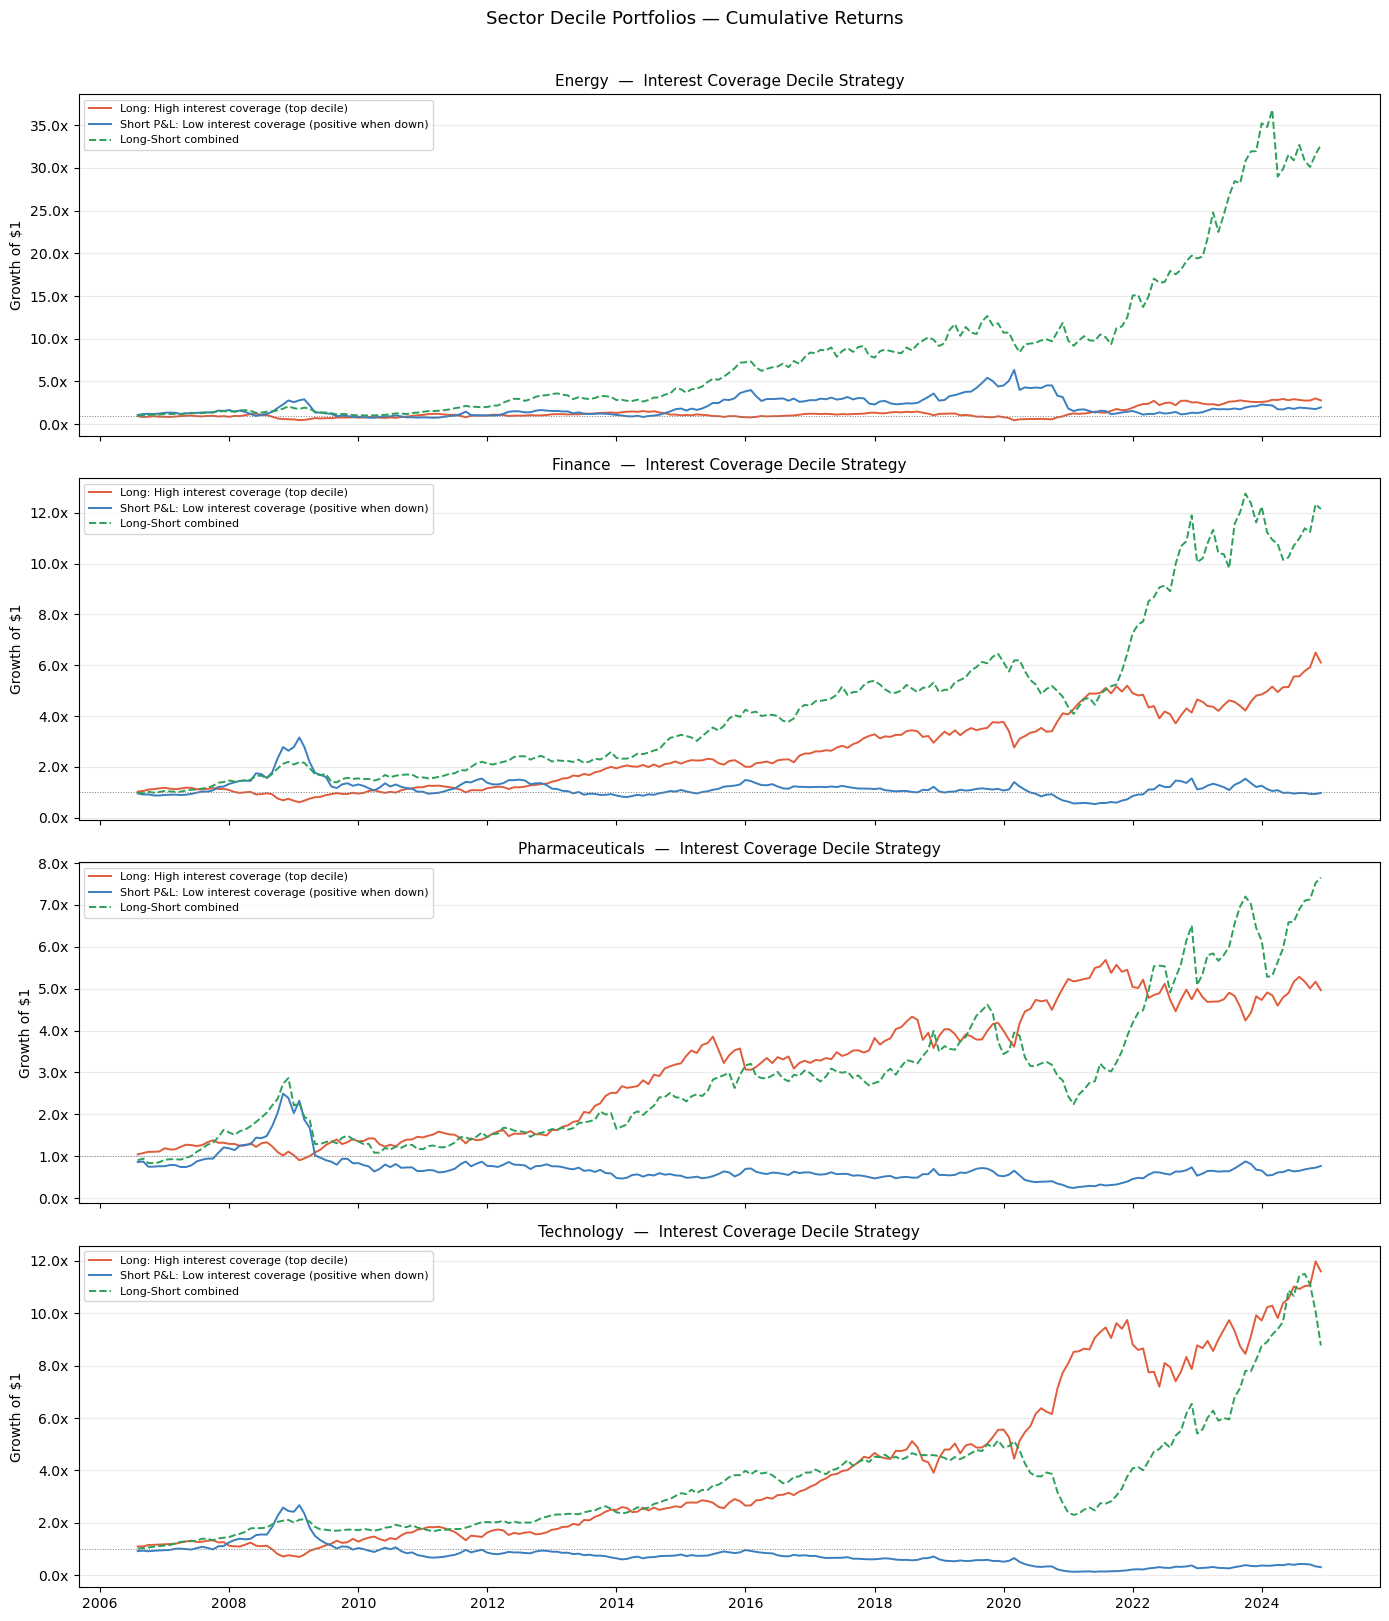

In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

n_sectors = len(SECTORS)
fig, axes = plt.subplots(n_sectors, 1, figsize=(14, 4 * n_sectors), sharex=True)
if n_sectors == 1:
    axes = [axes]
palette = {"top": "#e05c3a", "bot": "#3a7ebf", "ls": "#2ca05a"}

for ax, sector in zip(axes, SECTORS):
    col = sector.replace(" ", "_")
    top_c   = (1 + portfolio_ew[f"{col}_top_ret"].dropna()).cumprod()
    short_c = (1 + portfolio_ew[f"{col}_short_ret"].dropna()).cumprod()
    ls_c    = (1 + portfolio_ew[f"{col}_ls_ret"].dropna()).cumprod()
    ax.plot(top_c.index, top_c.values, color=palette["top"], linewidth=1.4,
            label=f"Long: High {test_variable.replace('_',' ')} (top decile)")
    ax.plot(short_c.index, short_c.values, color=palette["bot"], linewidth=1.4,
            label=f"Short P&L: Low {test_variable.replace('_',' ')} (positive when down)")
    ax.plot(ls_c.index, ls_c.values, color=palette["ls"], linewidth=1.4,
            linestyle="--", label="Long-Short combined")
    ax.axhline(1, color="gray", linewidth=0.7, linestyle=":")
    ax.set_title(f"{sector}  —  {test_variable.replace('_',' ').title()} Decile Strategy", fontsize=11)
    ax.set_ylabel("Growth of $1")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1fx"))
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(axis="y", alpha=0.25)

fig.suptitle("Sector Decile Portfolios — Cumulative Returns", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("sector_decile_strategy.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Summary statistics (equal-weight decile portfolios)

In [8]:
def summary_stats(r):
    r = r.dropna()
    if len(r) < 2:
        return {k: np.nan for k in ["Ann. Return (%)","Ann. Vol (%)","Sharpe","Max DD (%)","Win Rate (%)","Months"]}
    c = (1 + r).cumprod()
    mdd = ((c - c.cummax()) / c.cummax()).min()
    return {
        "Ann. Return (%)": round(((1 + r.mean())**12 - 1)*100, 2),
        "Ann. Vol (%)":    round(r.std()*np.sqrt(12)*100, 2),
        "Sharpe":          round((r.mean()/r.std())*np.sqrt(12), 2),
        "Max DD (%)":      round(mdd*100, 2),
        "Win Rate (%)":    round((r > 0).mean()*100, 2),
        "Months":          len(r),
    }

rows = {}
for sector in SECTORS:
    col = sector.replace(" ", "_")
    rows[f"{sector} — High"] = summary_stats(portfolio_ew[f"{col}_top_ret"])
    rows[f"{sector} — Low"]  = summary_stats(portfolio_ew[f"{col}_bot_ret"])
    rows[f"{sector} — L/S"]  = summary_stats(portfolio_ew[f"{col}_ls_ret"])
display(pd.DataFrame(rows).T)

,Ann. Return (%),Ann. Vol (%),Sharpe,Max DD (%),Win Rate (%),Months
Energy — High,10.58,30.05,0.34,-70.38,57.01,221.0
Energy — Low,-11.36,39.46,-0.30,-97.79,43.44,221.0
Energy — L/S,24.48,24.57,0.90,-51.44,61.99,221.0
Finance — High,12.04,17.60,0.65,-48.65,62.90,221.0
Finance — Low,-3.70,28.05,-0.13,-85.98,50.23,221.0
Finance — L/S,16.30,17.70,0.86,-36.69,63.35,221.0
Pharmaceuticals — High,10.59,16.57,0.61,-34.62,62.44,221.0
Pharmaceuticals — Low,-3.86,32.23,-0.12,-85.93,46.61,221.0
Pharmaceuticals — L/S,14.98,23.69,0.59,-62.20,63.80,221.0
Technology — High,16.45,19.74,0.78,-48.10,63.80,221.0


## 7. Vol-budgeted long-short backtest

Inverse-vol weighting, 12-month trailing-vol window ending at t-1, full long/short covariance, leverage cap, transaction costs subtracted.

In [9]:
PORTFOLIO_VALUE = 1_000_000
VOL_BUDGET      = 100_000
VOL_WINDOW      = 12
MAX_LEVERAGE    = 3.0
COST_PER_SIDE   = 0.0010

def get_trailing_vols(gvkeys, period, n_months=VOL_WINDOW):
    prev_period, start_period = period - 1, period - n_months
    valid = [g for g in gvkeys if g in available]
    if not valid:
        return pd.Series(dtype=float)
    window = monthly_returns.loc[start_period:prev_period, valid]
    vols = {}
    for g in valid:
        s = window[g].dropna()
        if len(s) < n_months // 2:
            continue
        v = s.std()
        if v > 0:
            vols[g] = v
    return pd.Series(vols)

def inv_vol_weights(gvkeys, vols):
    valid = [g for g in gvkeys if g in vols.index]
    if not valid:
        return pd.Series(dtype=float)
    inv = 1.0 / vols[valid]
    return inv / inv.sum()

def leg_monthly_returns(weights, period, n_months=VOL_WINDOW):
    """Leg return series over the trailing window.
    Each month uses only the stocks available that month, renormalizing weights —
    no fillna(0) bias, no whole-month dropping (so the series stays dense)."""
    prev_period, start_period = period - 1, period - n_months
    common = [g for g in weights.index if g in monthly_returns.columns]
    if not common:
        return pd.Series(dtype=float)
    w = weights[common]
    window = monthly_returns.loc[start_period:prev_period, common]

    def row_wret(r):
        avail = r.dropna()
        if avail.empty:
            return np.nan
        ww = w[avail.index]
        tot = ww.sum()
        if tot <= 0:
            return np.nan
        return float((ww / tot * avail).sum())

    return window.apply(row_wret, axis=1).dropna()

def ls_portfolio_vol(w_long, w_short, period):
    rl = leg_monthly_returns(w_long, period); rs = leg_monthly_returns(w_short, period)
    common = rl.index.intersection(rs.index)
    if len(common) < 3:
        return np.nan
    rl, rs = rl[common], rs[common]
    var_ls = rl.var() + rs.var() - 2 * rl.cov(rs)
    return float(np.sqrt(max(var_ls, 0.0)))

def weighted_return(weights, ret_row):
    common = weights.index.intersection(ret_row.dropna().index)
    if len(common) == 0:
        return np.nan, 0
    w = weights[common]; w = w / w.sum()
    return float((w * ret_row[common]).sum()), len(common)

results = []
NAN_FILL = ["ret", "ret_net", "long_ret", "short_ret", "leverage",
            "turnover_cost", "dollar_pnl", "n_long", "n_short"]
for period in sorted(df_ranks["period"].unique()):
    if period not in monthly_returns.index:
        continue
    ret_row = monthly_returns.loc[period]
    rank_period = period - 1
    row = {"date": period.to_timestamp()}
    for sector in SECTORS:
        col = sector.replace(" ", "_")
        top_g = top_df[(top_df["period"] == rank_period) & (top_df["industry"] == sector)]["gvkey"].tolist()
        bot_g = bot_df[(bot_df["period"] == rank_period) & (bot_df["industry"] == sector)]["gvkey"].tolist()
        vols = get_trailing_vols(top_g + bot_g, period)
        if vols.empty:
            for s in NAN_FILL: row[f"{col}_{s}"] = np.nan
            continue
        w_long, w_short = inv_vol_weights(top_g, vols), inv_vol_weights(bot_g, vols)
        if w_long.empty or w_short.empty:
            for s in NAN_FILL: row[f"{col}_{s}"] = np.nan
            continue
        r_long, n_long  = weighted_return(w_long, ret_row)
        r_short, n_short = weighted_return(w_short, ret_row)
        if np.isnan(r_long) or np.isnan(r_short):
            for s in NAN_FILL: row[f"{col}_{s}"] = np.nan
            continue
        vol_ls = ls_portfolio_vol(w_long, w_short, period)
        if np.isnan(vol_ls) or vol_ls == 0:
            for s in NAN_FILL: row[f"{col}_{s}"] = np.nan
            continue
        k = min(VOL_BUDGET / (vol_ls * PORTFOLIO_VALUE), MAX_LEVERAGE)
        r_scaled = k * (r_long - r_short)
        turnover_cost = 2 * k * COST_PER_SIDE
        r_net = r_scaled - turnover_cost
        row[f"{col}_ret"]           = r_scaled
        row[f"{col}_ret_net"]       = r_net
        row[f"{col}_long_ret"]      = r_long
        row[f"{col}_short_ret"]     = -r_short
        row[f"{col}_leverage"]      = k
        row[f"{col}_turnover_cost"] = turnover_cost
        row[f"{col}_dollar_pnl"]    = r_net * PORTFOLIO_VALUE
        row[f"{col}_n_long"]        = n_long
        row[f"{col}_n_short"]       = n_short
    results.append(row)

portfolio = pd.DataFrame(results).set_index("date").sort_index()
print(f"Vol-budgeted portfolio built: {len(portfolio)} months")

Vol-budgeted portfolio built: 224 months


## 8. Vol-budgeted L/S — per-sector portfolio value + leverage

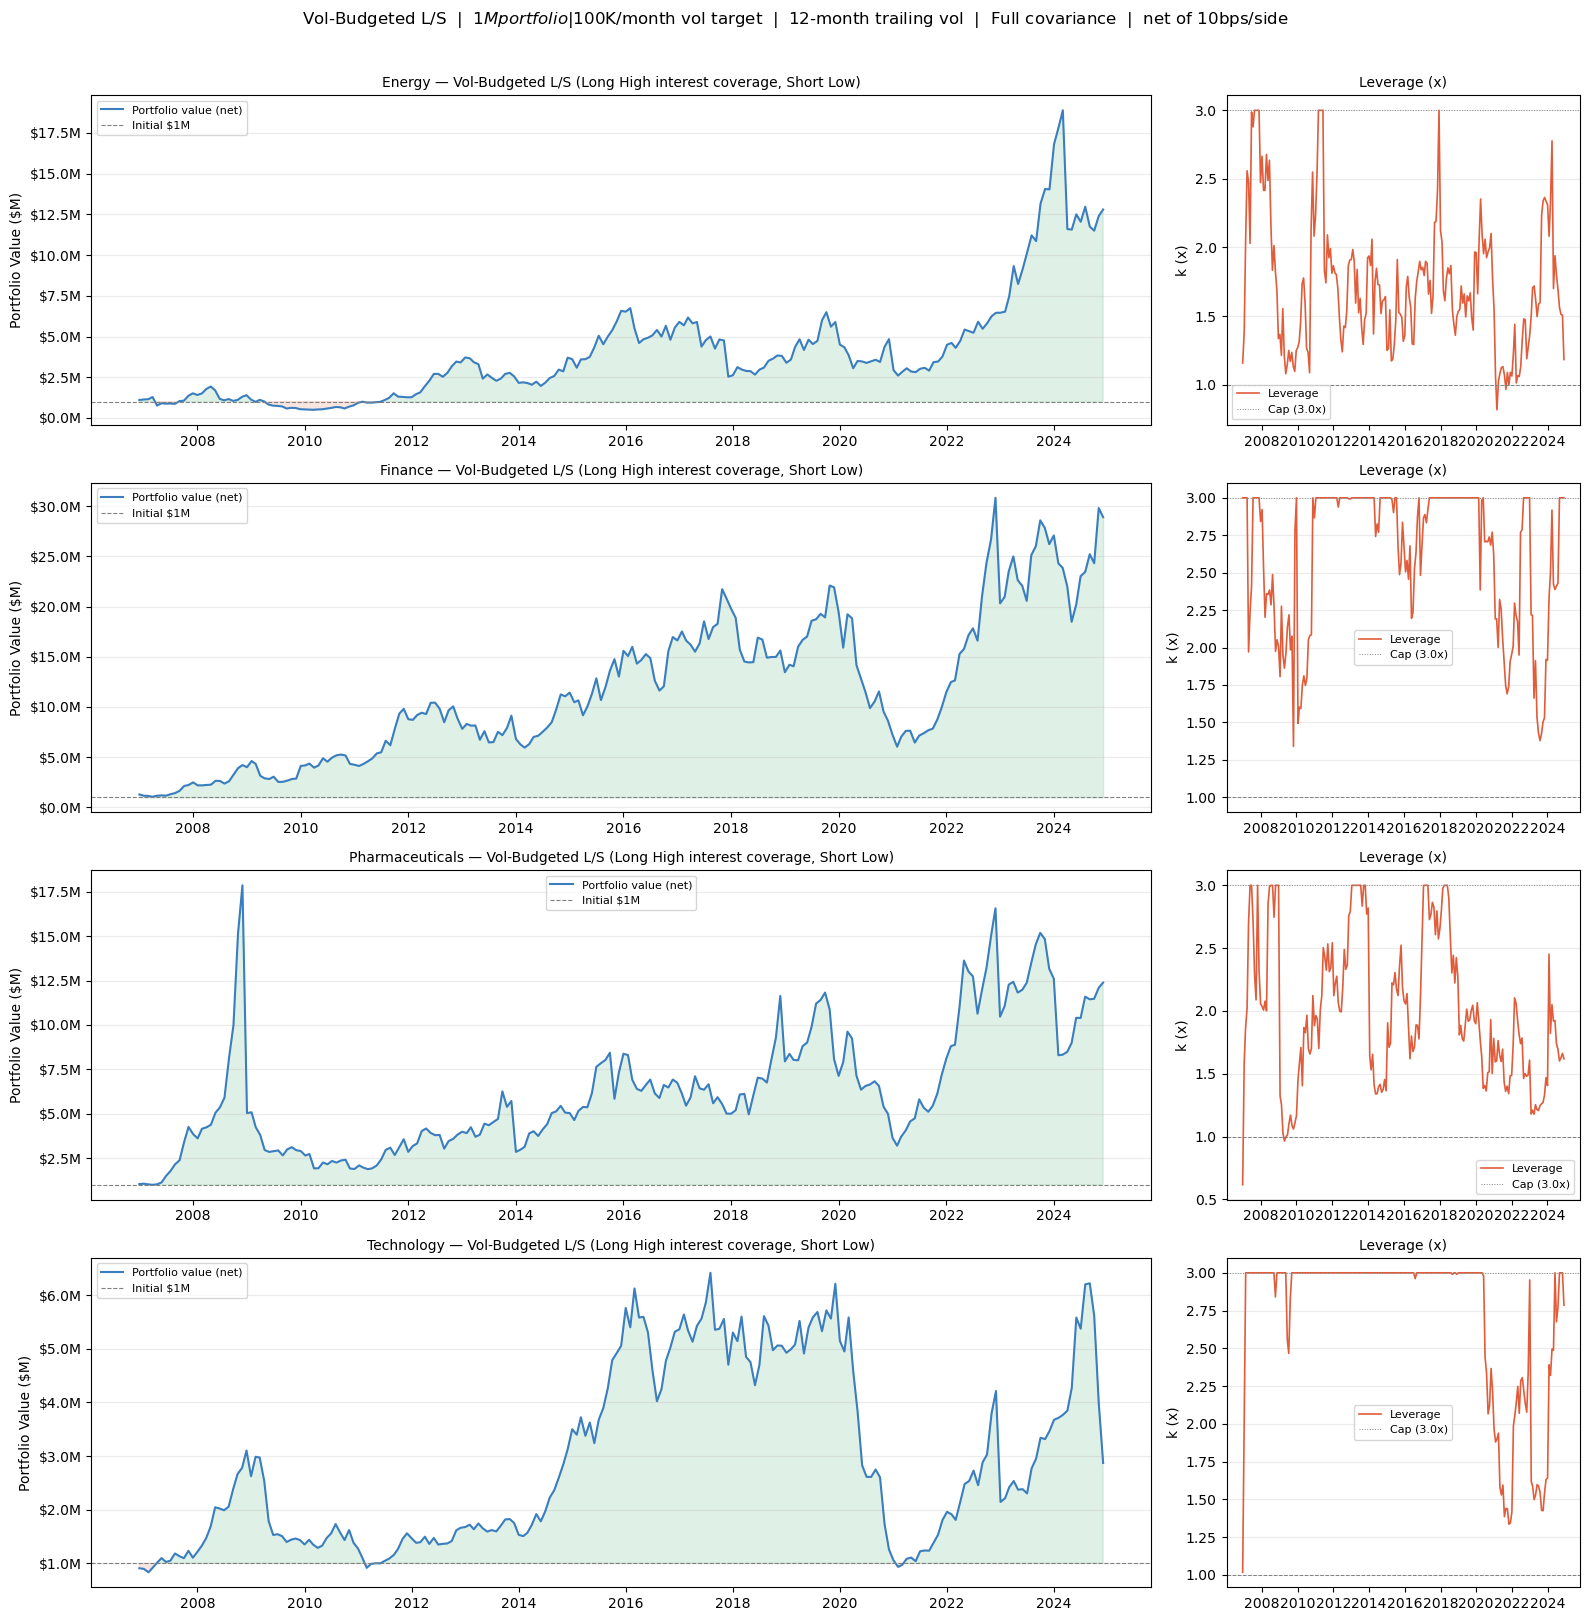

In [10]:
fig, axes = plt.subplots(len(SECTORS), 2, figsize=(16, 4 * len(SECTORS)),
                         gridspec_kw={"width_ratios": [3, 1]})
if len(SECTORS) == 1:
    axes = [axes]

for row_axes, sector in zip(axes, SECTORS):
    col = sector.replace(" ", "_")
    ax_cum, ax_lev = row_axes

    r_series = portfolio[f"{col}_ret_net"].dropna()
    cum_val  = PORTFOLIO_VALUE * (1 + r_series).cumprod()

    ax_cum.plot(cum_val.index, cum_val.values / 1e6, color="#3a7ebf", linewidth=1.5,
                label="Portfolio value (net)")
    ax_cum.axhline(PORTFOLIO_VALUE / 1e6, color="gray", linewidth=0.8, linestyle="--",
                   label="Initial $1M")
    ax_cum.fill_between(cum_val.index, PORTFOLIO_VALUE / 1e6, cum_val.values / 1e6,
                        where=cum_val.values >= PORTFOLIO_VALUE, alpha=0.15, color="#2ca05a")
    ax_cum.fill_between(cum_val.index, PORTFOLIO_VALUE / 1e6, cum_val.values / 1e6,
                        where=cum_val.values < PORTFOLIO_VALUE, alpha=0.15, color="#e05c3a")
    ax_cum.set_title(f"{sector} — Vol-Budgeted L/S "
                     f"(Long High {test_variable.replace('_',' ')}, Short Low)", fontsize=10)
    ax_cum.set_ylabel("Portfolio Value ($M)")
    ax_cum.legend(fontsize=8)
    ax_cum.grid(axis="y", alpha=0.25)
    ax_cum.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.1f}M"))

    lev = portfolio[f"{col}_leverage"].dropna()
    ax_lev.plot(lev.index, lev.values, color="#e05c3a", linewidth=1.2, label="Leverage")
    ax_lev.axhline(1.0, color="gray", linewidth=0.7, linestyle="--")
    ax_lev.axhline(MAX_LEVERAGE, color="#888", linewidth=0.7, linestyle=":", label=f"Cap ({MAX_LEVERAGE}x)")
    ax_lev.set_title("Leverage (x)", fontsize=10)
    ax_lev.set_ylabel("k (x)")
    ax_lev.legend(fontsize=8)
    ax_lev.grid(axis="y", alpha=0.25)

fig.suptitle(
    f"Vol-Budgeted L/S  |  $1M portfolio  |  $100K/month vol target  |  "
    f"{VOL_WINDOW}-month trailing vol  |  Full covariance  |  net of {COST_PER_SIDE*1e4:.0f}bps/side",
    fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("vol_budgeted_ls.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Vol-budgeted summary statistics (gross & net)

In [11]:
rows = {}
for sector in SECTORS:
    col = sector.replace(" ", "_")
    rows[f"{sector} (gross)"] = summary_stats(portfolio[f"{col}_ret"])
    rows[f"{sector} (net)"]   = summary_stats(portfolio[f"{col}_ret_net"])
    rows[f"{sector} (net)"]["Avg Leverage"] = round(portfolio[f"{col}_leverage"].dropna().mean(), 2)
    rows[f"{sector} (net)"]["Total P&L ($)"] = "${:,.0f}".format(portfolio[f"{col}_dollar_pnl"].dropna().sum())
display(pd.DataFrame(rows).T)

,Ann. Return (%),Ann. Vol (%),Sharpe,Max DD (%),Win Rate (%),Months,Avg Leverage,Total P&L ($)
Energy (gross),32.35,43.01,0.66,-72.03,60.37,217.0,NaN,NaN
Energy (net),27.06,43.04,0.56,-74.04,58.99,217,1.74,"$4,374,822"
Finance (gross),38.52,39.95,0.83,-70.05,60.65,216.0,NaN,NaN
Finance (net),30.25,39.95,0.67,-72.65,59.72,216,2.63,"$4,809,763"
Pharmaceuticals (gross),39.34,50.64,0.66,-88.61,63.89,216.0,NaN,NaN
Pharmaceuticals (net),32.95,50.59,0.57,-89.5,62.04,216,2.01,"$5,187,218"
Technology (gross),22.11,37.76,0.53,-83.69,61.75,217.0,NaN,NaN
Technology (net),14.45,37.79,0.36,-85.45,59.91,217,2.74,"$2,454,301"


## 10. Two-Fund Separation (analytical max-Sharpe across sectors)

Closed-form tangency portfolio **W_SR = Σ⁻¹E[Rᵉ]** over the sector L/S returns, rolling 12-month window. 

Sector portfolios: ['Energy', 'Energy long', 'Energy short', 'Finance', 'Finance long', 'Finance short', 'Pharmaceuticals', 'Pharmaceuticals long', 'Pharmaceuticals short', 'Technology', 'Technology long', 'Technology short']
MVO portfolio built: 205 months (2007-12 -> 2024-12)


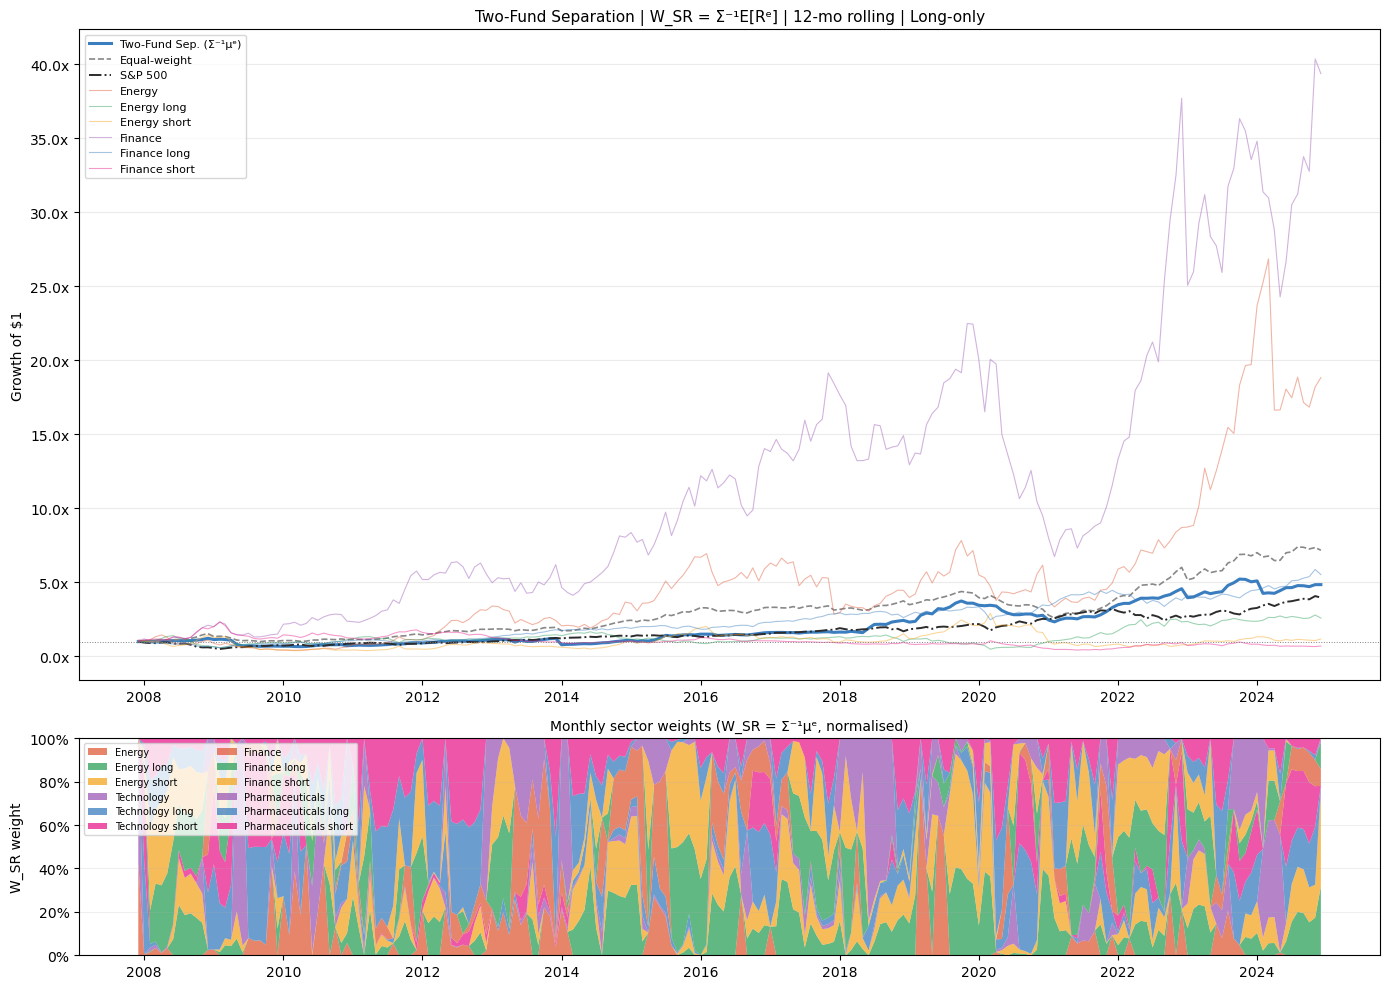

In [12]:
import yfinance as yf

MVO_WINDOW = 12
RF = 0.0
LONG_ONLY = True

ret_cols = [c for c in portfolio.columns if c.endswith("_ret")]
sector_rets = portfolio[ret_cols].copy()
sector_rets.columns = [c.replace("_ret", "").replace("_", " ") for c in ret_cols]
print(f"Sector portfolios: {sector_rets.columns.tolist()}")

def tangency_weights(mu_e, cov):
    n = len(mu_e); ew = np.ones(n) / n
    if np.all(mu_e <= 0):
        return ew
    try:
        w_sr = np.linalg.solve(cov, mu_e)
    except np.linalg.LinAlgError:
        return ew
    if LONG_ONLY:
        w_sr = np.clip(w_sr, 0, None)
    total = w_sr.sum()
    if total <= 0 or not np.isfinite(total):
        return ew
    return w_sr / total

mvo_results = []
for i in range(MVO_WINDOW, len(sector_rets)):
    current_date = sector_rets.index[i]
    window = sector_rets.iloc[i - MVO_WINDOW : i]
    valid_cols = window.columns[window.notna().all()].tolist()
    if len(valid_cols) < 2:
        continue
    wc = window[valid_cols].values
    mu_e = wc.mean(axis=0) - RF
    cov = np.cov(wc, rowvar=False) + np.eye(len(valid_cols)) * 1e-8
    w_opt = pd.Series(tangency_weights(mu_e, cov), index=valid_cols)
    current_rets = sector_rets.loc[current_date, valid_cols]
    if current_rets.isna().any():
        continue
    row = {"date": current_date,
           "mvo_ret": float(w_opt @ current_rets.values),
           "ew_ret": float(current_rets.mean())}
    for sector, w in w_opt.items():
        row[f"w_{sector}"] = w
    mvo_results.append(row)

mvo = pd.DataFrame(mvo_results).set_index("date").sort_index()
print(f"MVO portfolio built: {len(mvo)} months "
      f"({mvo.index[0]:%Y-%m} -> {mvo.index[-1]:%Y-%m})")

# --- S&P 500 benchmark, aligned with NO gaps ---
sp_raw = yf.download("^GSPC", start=mvo.index[0] - pd.DateOffset(months=1),
                     end=mvo.index[-1] + pd.DateOffset(months=1),
                     interval="1mo", auto_adjust=True, progress=False)["Close"]
sp500_ret = sp_raw.squeeze().pct_change().dropna()
sp500_ret.index = sp500_ret.index.to_period("M")           # period key
mvo_periods = mvo.index.to_period("M")
common_p = mvo_periods.intersection(sp500_ret.index)        # only overlapping months
sp500_ret = sp500_ret.loc[common_p]
sp500_ret.index = sp500_ret.index.to_timestamp()            # back to timestamps (no NaN gaps)
sp500_ret.name = "SP500"

# --- chart ---
sector_colors = ["#e05c3a", "#2ca05a", "#f5a623", "#9b59b6", "#3a7ebf", "#e91e8c"]
fig, (ax, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={"height_ratios": [3, 1]})
cum_mvo = (1 + mvo["mvo_ret"]).cumprod(); cum_ew = (1 + mvo["ew_ret"]).cumprod()
ax.plot(cum_mvo.index, cum_mvo.values, color="#3a7ebf", linewidth=2.2, label="Two-Fund Sep. (Σ⁻¹μᵉ)")
ax.plot(cum_ew.index, cum_ew.values, color="#888", linewidth=1.2, linestyle="--", label="Equal-weight")
cum_sp = (1 + sp500_ret).cumprod()
ax.plot(cum_sp.index, cum_sp.values, color="#2c2c2c", linewidth=1.4, linestyle="-.", label="S&P 500")
for col, color in zip(sector_rets.columns, sector_colors):
    r = sector_rets[col].reindex(mvo.index).dropna(); c = (1 + r).cumprod()
    ax.plot(c.index, c.values, color=color, linewidth=0.8, alpha=0.45, label=col)
ax.axhline(1, color="gray", linewidth=0.7, linestyle=":")
ax.set_ylabel("Growth of $1")
ax.set_title("Two-Fund Separation | W_SR = Σ⁻¹E[Rᵉ] | 12-mo rolling | Long-only", fontsize=11)
ax.legend(fontsize=8, loc="upper left"); ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1fx"))
ax.grid(axis="y", alpha=0.25)
weight_cols = [c for c in mvo.columns if c.startswith("w_")]
wt = mvo[weight_cols].fillna(0); wt.columns = [c.replace("w_", "") for c in weight_cols]
ax2.stackplot(wt.index, [wt[c].values for c in wt.columns], labels=wt.columns,
              colors=sector_colors[:len(wt.columns)], alpha=0.75)
ax2.set_ylabel("W_SR weight"); ax2.set_ylim(0, 1)
ax2.set_title("Monthly sector weights (W_SR = Σ⁻¹μᵉ, normalised)", fontsize=10)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.legend(fontsize=7, loc="upper left", ncol=2); ax2.grid(axis="y", alpha=0.2)
plt.tight_layout(); plt.savefig("mvo_portfolio.png", dpi=150, bbox_inches="tight"); plt.show()

## 11. Appraisal Ratio + full performance attribution vs S&P 500

Performance Attribution vs S&P 500 (Rf = 0.0% p.a.)



,Ann. Return (%),Ann. Vol (%),Sharpe Ratio,Alpha (ann. %),Alpha t-stat,Alpha p-value,Beta,Beta t-stat,Beta p-value,R2,Resid. Vol (ann. %),Appraisal Ratio,N months
Strategy,,,,,,,,,,,,,
Energy L/S,30.26,42.02,0.636,28.50,2.45,0.0150,0.149,8.000000e-01,0.4219,0.003,41.86,0.681,205
Energy long L/S,9.94,28.00,0.340,-1.42,-0.28,0.7820,1.167,1.264000e+01,0.0000,0.440,20.89,-0.068,205
Energy short L/S,8.72,37.65,0.223,20.49,2.30,0.0227,-1.109,-7.560000e+00,0.0000,0.220,33.18,0.618,205
Finance L/S,33.70,39.47,0.745,41.68,3.77,0.0002,-0.635,-3.770000e+00,0.0002,0.066,38.06,1.095,205
Finance long L/S,12.06,16.58,0.690,2.78,1.48,0.1416,0.927,2.776000e+01,0.0000,0.792,7.55,0.369,205
Finance short L/S,0.92,24.90,0.037,13.03,3.19,0.0016,-1.216,-1.758000e+01,0.0000,0.604,15.64,0.833,205
Pharmaceuticals L/S,30.63,49.97,0.541,41.93,3.02,0.0029,-0.908,-4.300000e+00,0.0000,0.084,47.72,0.879,205
Pharmaceuticals long L/S,10.87,15.02,0.690,3.43,1.49,0.1377,0.746,1.837000e+01,0.0000,0.624,9.18,0.373,205
Pharmaceuticals short L/S,2.10,31.39,0.066,14.23,2.19,0.0298,-1.205,-1.100000e+01,0.0000,0.373,24.79,0.574,205


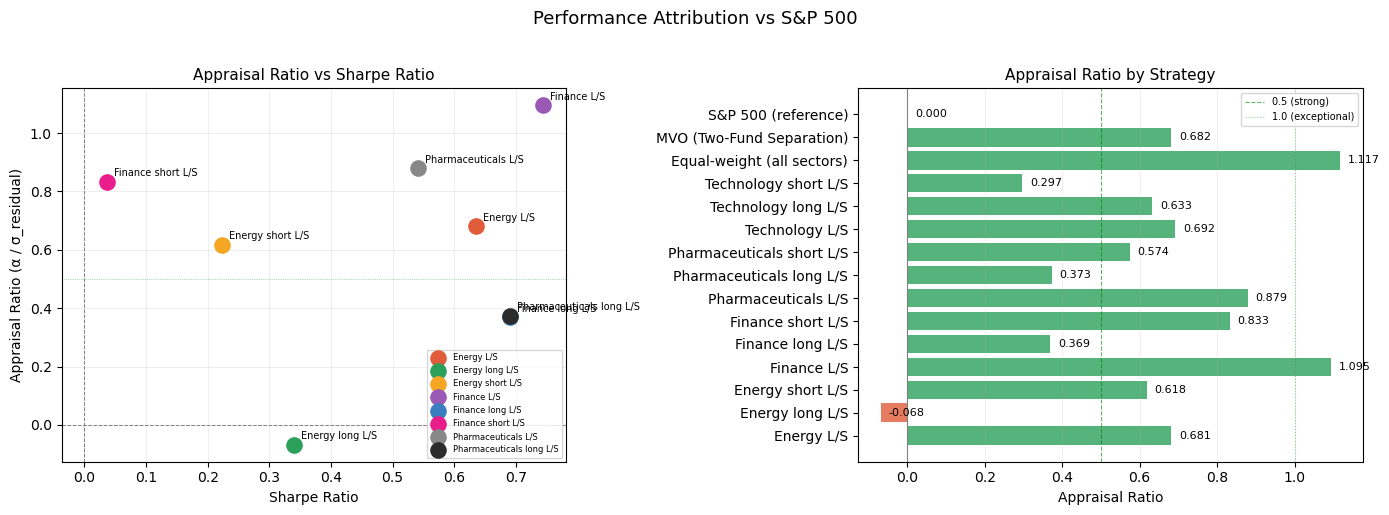


Appraisal Ratio = Annualised Alpha / Annualised Residual Volatility
  Alpha per unit of idiosyncratic (active) risk.
  > 0.5 strong | > 1.0 exceptional | < 0 active bets destroyed value.
  Sharpe penalises ALL volatility; Appraisal only idiosyncratic.
  Market-neutral L/S (beta ~ 0) -> they converge.



In [13]:
import statsmodels.api as sm

RF_ANNUAL = 0.00
RF_MONTHLY = (1 + RF_ANNUAL) ** (1/12) - 1

def full_metrics(r_strategy, r_market, label, rf_monthly=RF_MONTHLY):
    d = pd.concat([r_strategy.rename("s"), r_market.rename("m")], axis=1).dropna()
    if len(d) < 12:
        return {"Strategy": label, "Note": "< 12 months of data"}
    r = d["s"]
    excess = r - rf_monthly
    sharpe = (excess.mean() / excess.std()) * np.sqrt(12)
    X = sm.add_constant(d["m"].values)
    ols = sm.OLS(d["s"].values, X).fit()
    alpha_m, beta = ols.params[0], ols.params[1]
    alpha_ann = (1 + alpha_m) ** 12 - 1
    resid_vol_ann = ols.resid.std() * np.sqrt(12)
    appraisal = alpha_ann / resid_vol_ann if resid_vol_ann > 0 else np.nan
    return {
        "Strategy": label,
        "Ann. Return (%)": round(((1 + r.mean())**12 - 1)*100, 2),
        "Ann. Vol (%)":    round(r.std()*np.sqrt(12)*100, 2),
        "Sharpe Ratio":    round(sharpe, 3),
        "Alpha (ann. %)":  round(alpha_ann*100, 2),
        "Alpha t-stat":    round(ols.tvalues[0], 2),
        "Alpha p-value":   round(ols.pvalues[0], 4),
        "Beta":            round(beta, 3),
        "Beta t-stat":     round(ols.tvalues[1], 2),
        "Beta p-value":    round(ols.pvalues[1], 4),
        "R2":              round(ols.rsquared, 3),
        "Resid. Vol (ann. %)": round(resid_vol_ann*100, 2),
        "Appraisal Ratio": round(appraisal, 3),
        "N months":        len(d),
    }

strategies = []
for col in ret_cols:
    name = col.replace("_ret", "").replace("_", " ")
    strategies.append((portfolio[col].dropna(), f"{name} L/S"))
ew_ret_all = portfolio[ret_cols].mean(axis=1).dropna()
strategies.append((ew_ret_all, "Equal-weight (all sectors)"))
try:
    strategies.append((mvo["mvo_ret"].dropna(), "MVO (Two-Fund Separation)"))
except NameError:
    pass
strategies.append((sp500_ret, "S&P 500 (reference)"))

results_attr = pd.DataFrame([full_metrics(r, sp500_ret, label) for r, label in strategies]).set_index("Strategy")
print(f"Performance Attribution vs S&P 500 (Rf = {RF_ANNUAL*100:.1f}% p.a.)\n")
display(results_attr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ["#e05c3a", "#2ca05a", "#f5a623", "#9b59b6", "#3a7ebf", "#e91e8c", "#888", "#2c2c2c"]
ax = axes[0]
pr = results_attr.dropna(subset=["Appraisal Ratio", "Sharpe Ratio"])
for (idx, rd), color in zip(pr.iterrows(), colors):
    ax.scatter(rd["Sharpe Ratio"], rd["Appraisal Ratio"], s=120, color=color, zorder=3, label=idx)
    ax.annotate(idx.split("(")[0].strip(), (rd["Sharpe Ratio"], rd["Appraisal Ratio"]),
                fontsize=7, xytext=(5, 4), textcoords="offset points")
ax.axhline(0, color="gray", linewidth=0.7, linestyle="--"); ax.axvline(0, color="gray", linewidth=0.7, linestyle="--")
ax.axhline(0.5, color="green", linewidth=0.5, linestyle=":", alpha=0.6)
ax.set_xlabel("Sharpe Ratio"); ax.set_ylabel("Appraisal Ratio (α / σ_residual)")
ax.set_title("Appraisal Ratio vs Sharpe Ratio", fontsize=11); ax.legend(fontsize=6, loc="lower right"); ax.grid(alpha=0.2)
ax2 = axes[1]
ar = results_attr["Appraisal Ratio"].dropna()
bars = ax2.barh(ar.index, ar.values, color=["#2ca05a" if v > 0 else "#e05c3a" for v in ar], alpha=0.8)
ax2.axvline(0, color="gray", linewidth=0.8)
ax2.axvline(0.5, color="green", linewidth=0.8, linestyle="--", alpha=0.6, label="0.5 (strong)")
ax2.axvline(1.0, color="green", linewidth=0.8, linestyle=":", alpha=0.4, label="1.0 (exceptional)")
for bar, val in zip(bars, ar.values):
    ax2.text(val + 0.02, bar.get_y() + bar.get_height()/2, f"{val:.3f}", va="center", fontsize=8)
ax2.set_xlabel("Appraisal Ratio"); ax2.set_title("Appraisal Ratio by Strategy", fontsize=11)
ax2.legend(fontsize=7); ax2.grid(axis="x", alpha=0.2)
plt.suptitle("Performance Attribution vs S&P 500", fontsize=13, y=1.02)
plt.tight_layout(); plt.savefig("appraisal_ratio.png", dpi=150, bbox_inches="tight"); plt.show()

print("""
Appraisal Ratio = Annualised Alpha / Annualised Residual Volatility
  Alpha per unit of idiosyncratic (active) risk.
  > 0.5 strong | > 1.0 exceptional | < 0 active bets destroyed value.
  Sharpe penalises ALL volatility; Appraisal only idiosyncratic.
  Market-neutral L/S (beta ~ 0) -> they converge.
""")

## Notes

**Charts included:**
1. Per-sector decile cumulative (Long / Short P&L / Long-Short) — Section 5
2. **Per-sector vol-budgeted value + leverage grid** — Section 8
3. Two-Fund Separation vs S&P 500 + sector-weight stackplot — Section 10
4. Appraisal-Ratio scatter + bar — Section 11